In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

from analysis_lib.decoder import RawDecoder, BrotherSerialDecoder
from analysis_lib.plotting import plot_digital, plot_digital_normalized
from analysis_lib.capture import Capture
from analysis_lib.constants import DEFAULT_LABELS

DEBUG_LABELS = ["D_SI_PATH", "D_SO_PATH", "D_STATE", "D_KBRQ_F"]


In [2]:
CAPTURES = [
    # --- IF-60 Captures (6 channels, Anhang I) ---
    {
        "path": "./signal_captures/AX20_IF60/AX20_IF60_POWERON_SEG1.pkl",
        "output_name": "capture_AX20_IF60_POWERON",
        "debug_pins": False,
        "time_zero_at_us": 1448381.25,
        "time_range_us": (-20, 1075),
    },
    {
        "path": "./signal_captures/AX20_IF60/AX20_IF60_SELECT.pkl",
        "output_name": "capture_AX20_IF60_SELECT",
        "debug_pins": False,
        "time_zero_at_us": -0.03,
        "time_range_us": (-20, 6650),
    },
    {
        "path": "./signal_captures/AX20_IF60/AX20_IF60_DESELECT.pkl",
        "output_name": "capture_AX20_IF60_DESELECT",
        "debug_pins": False,
        "time_zero_at_us": -1.0,
        "time_range_us": (-20, 450),
    },
    {
        "path": "./signal_captures/AX20_IF60/AX20_IF60_ASCII_65.pkl",
        "output_name": "capture_AX20_IF60_ASCII_65",
        "debug_pins": False,
        "time_zero_at_us": -2.0,
        "time_range_us": (-20, 700),
    },
    # --- Adapter Captures (10 channels, Anhang J + Kap. 5) ---
    {
        "path": "./signal_captures/AX20_IFARDUINO/AX20_IFARDUINO_POWERON_SEG0.pkl",
        "output_name": "capture_AX20_ADAPTER_POWERON",
        "debug_pins": True,
        "time_zero_at_us": -0.5,
        "time_range_us": (-20, 1100),
    },
    {
        "path": "./signal_captures/AX20_IFARDUINO/AX20_IFARDUINO_ASCII_A.pkl",
        "output_name": "capture_AX20_ADAPTER_ASCII_65",
        "debug_pins": True,
        "time_zero_at_us": 0.0,
        "time_range_us": (-20, 650),
    },
]

OUTPUT_DIR = "./svg_output"
# Raw captures (no normalization, no decoding) — for inline figures in main text
RAW_CAPTURES = [
    {
        "path": "./signal_captures/AX20_IF60/AX20_IF60_POWERON_SEG1.pkl",
        "output_name": "capture_AX20_IF60_POWERON_intro",
        "time_range_us": (100, 1150),
    },
]


In [3]:
import numpy as np
def process_capture(config):
    """Load, decode, and plot a single capture. Returns (name, fig)."""
    capture = Capture.load(config['path'])
    time_data = capture.time_data
    channel_data = capture.channel_data

    # Optional time-zero shift (subtract absolute event reference)
    if "time_zero_at_us" in config:
        time_data = time_data - config["time_zero_at_us"] * 1e-6

    # Optional time range trimming (in µs)
    if "time_range_us" in config:
        t_min, t_max = config['time_range_us']
        mask = (time_data >= t_min * 1e-6) & (time_data <= t_max * 1e-6)
        idx = np.where(mask)[0]
        time_data = time_data[idx]
        channel_data = {ch: arr[idx] for ch, arr in channel_data.items()}

    # Decode SI (ch 0) and SO (ch 1)
    raw_decoder = RawDecoder(channel_data, time_data)
    raw_si = raw_decoder.decode(data_ch=0)
    raw_so = raw_decoder.decode(data_ch=1)

    decoded_si = BrotherSerialDecoder(raw_si).decode()
    decoded_so = BrotherSerialDecoder(raw_so).decode()

    annotations = (
        decoded_si.to_annotations(include_bits=True) +
        decoded_so.to_annotations(include_bits=True)
    )

    # Normalization point 17µs after the last rising SCK edge of each byte
    frame_end_times = [frame.end_time + 17e-6 for frame in raw_si.frames]

    # Set labels, channel order, normalization and extra warp channels
    if config['debug_pins'] and len(channel_data) > 6:
        labels = DEFAULT_LABELS + DEBUG_LABELS
        channels = list(range(len(labels)))
        extra_warp = [6, 7, 8, 9]
        figsize = (12, 7)
    else:
        labels = DEFAULT_LABELS
        channels = list(range(6))
        extra_warp = None
        figsize = (12, 5)

    fig, ax = plot_digital_normalized(
        time_data, channel_data,
        channels=channels,
        normalization_rising_only_channels=[3],  # KBACK rising edges only
        extra_warp_channels=extra_warp,
        extra_norm_times=frame_end_times,
        labels=labels,
        annotations=annotations,
        figsize=figsize,
        title="",  # title set in LaTeX caption
        show=False,
    )

    return config['output_name'], fig


def process_capture_raw(config):
    """Load and plot a capture without normalization or decoding."""
    capture = Capture.load(config['path'])
    time_data = capture.time_data
    channel_data = capture.channel_data

    # Zero the time axis (remove absolute offset from .pkl file)
    time_data = time_data - time_data[0]

    if "time_range_us" in config:
        t_min, t_max = config['time_range_us']
        mask = (time_data >= t_min * 1e-6) & (time_data <= t_max * 1e-6)
        idx = np.where(mask)[0]
        time_data = time_data[idx]
        channel_data = {ch: arr[idx] for ch, arr in channel_data.items()}

    fig, ax = plot_digital(
        time_data, channel_data,
        channels=list(range(6)),
        labels=DEFAULT_LABELS,
        time_unit="us",
        figsize=(12, 5),
        title="",
        clock_markers=None,
        show=False,
    )

    return config['output_name'], fig


## IF-60 Captures (Anhang I)
POWERON, SELECT, DESELECT, ASCII 65 — all 6 standard channels.

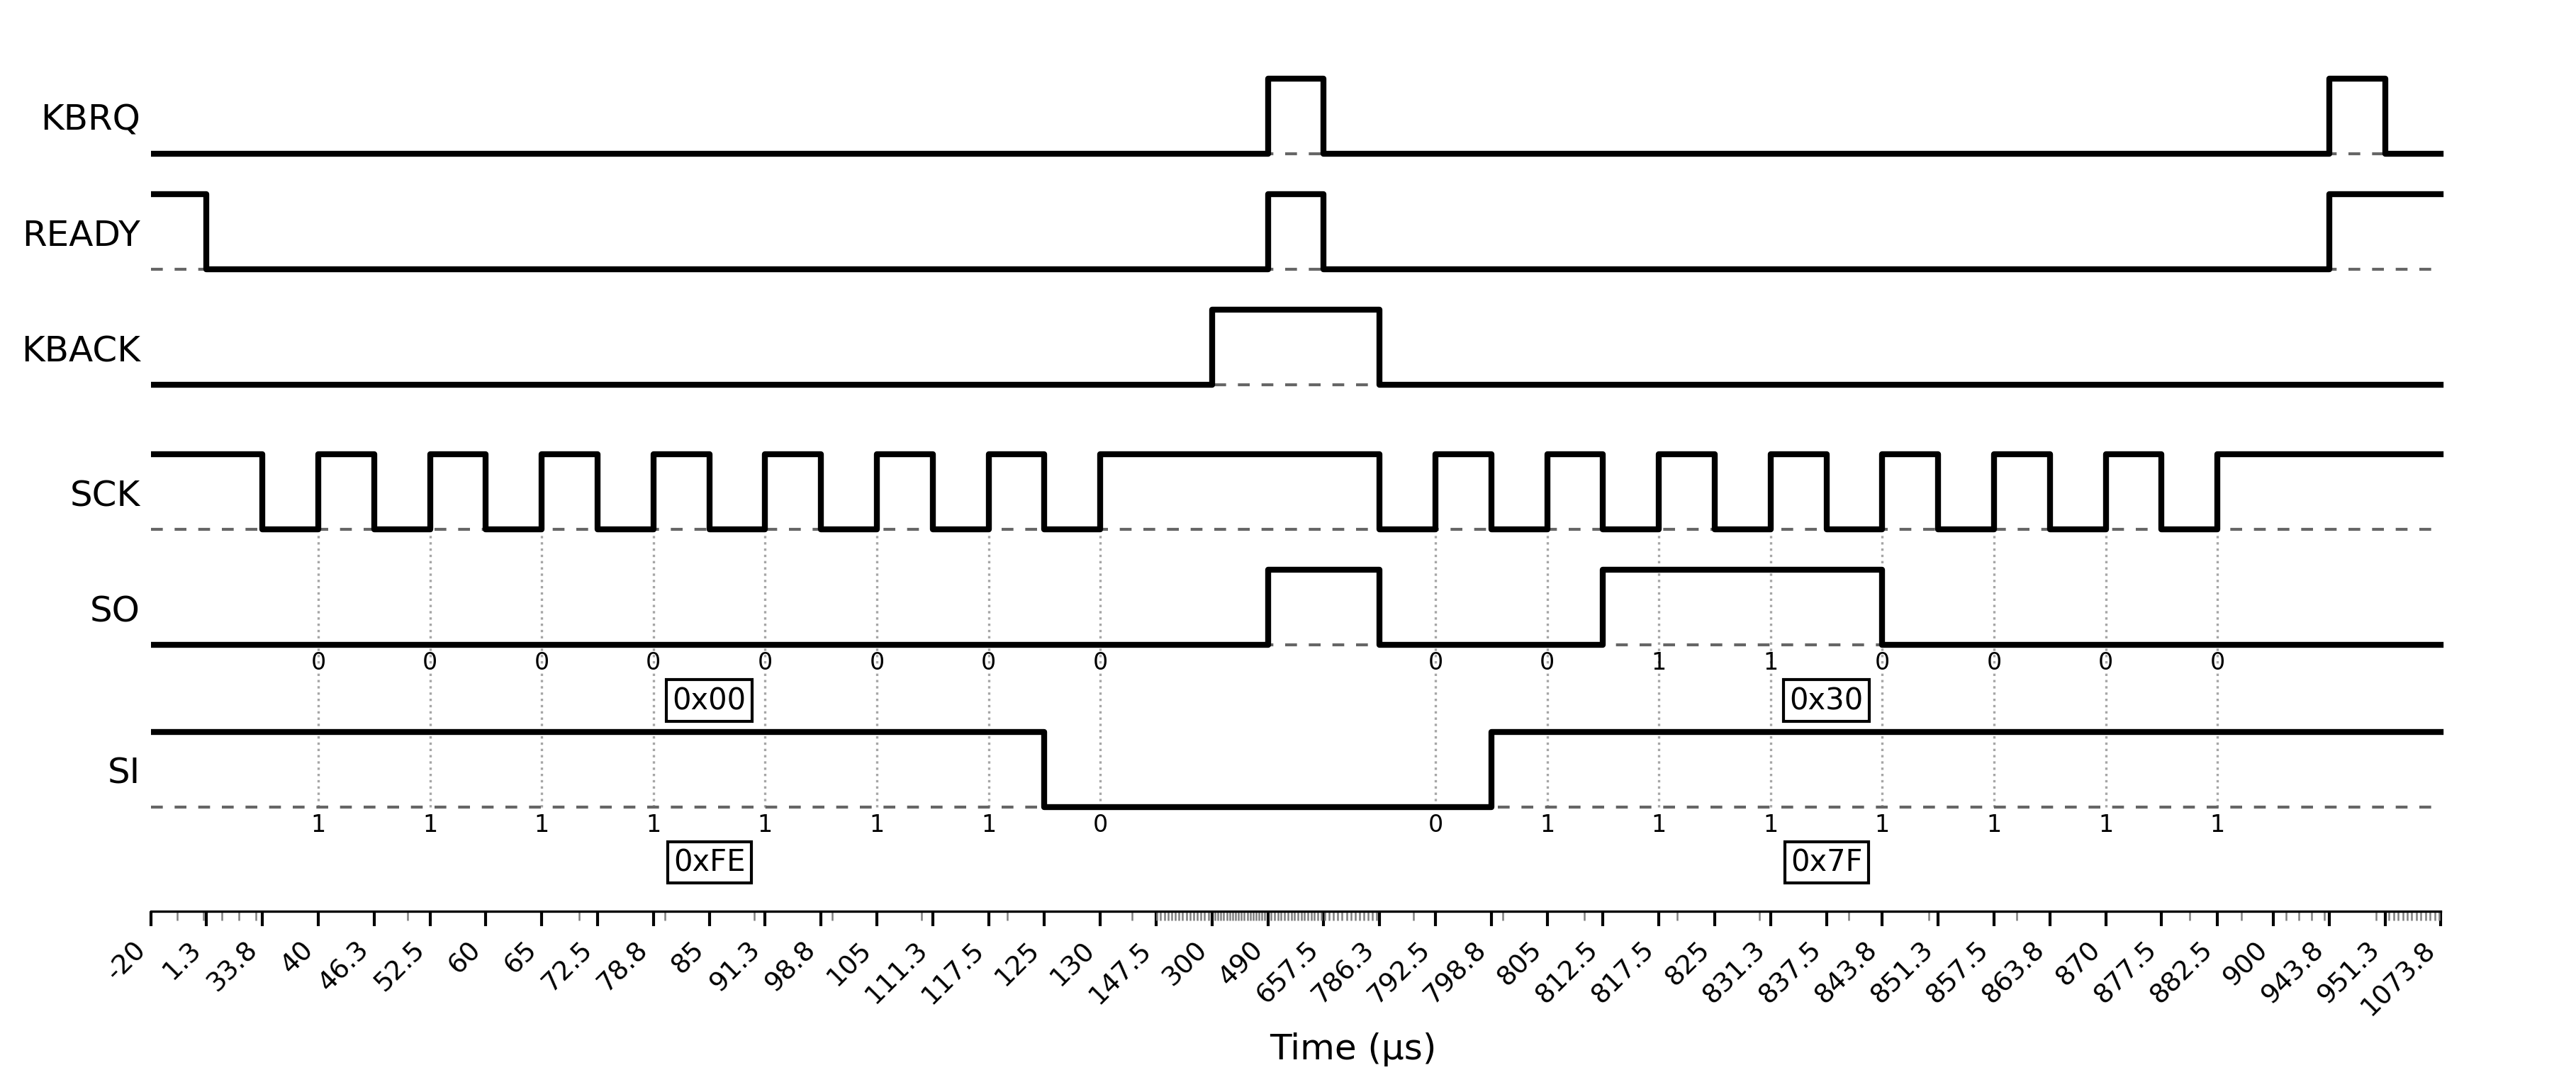

--- capture_AX20_IF60_POWERON ---


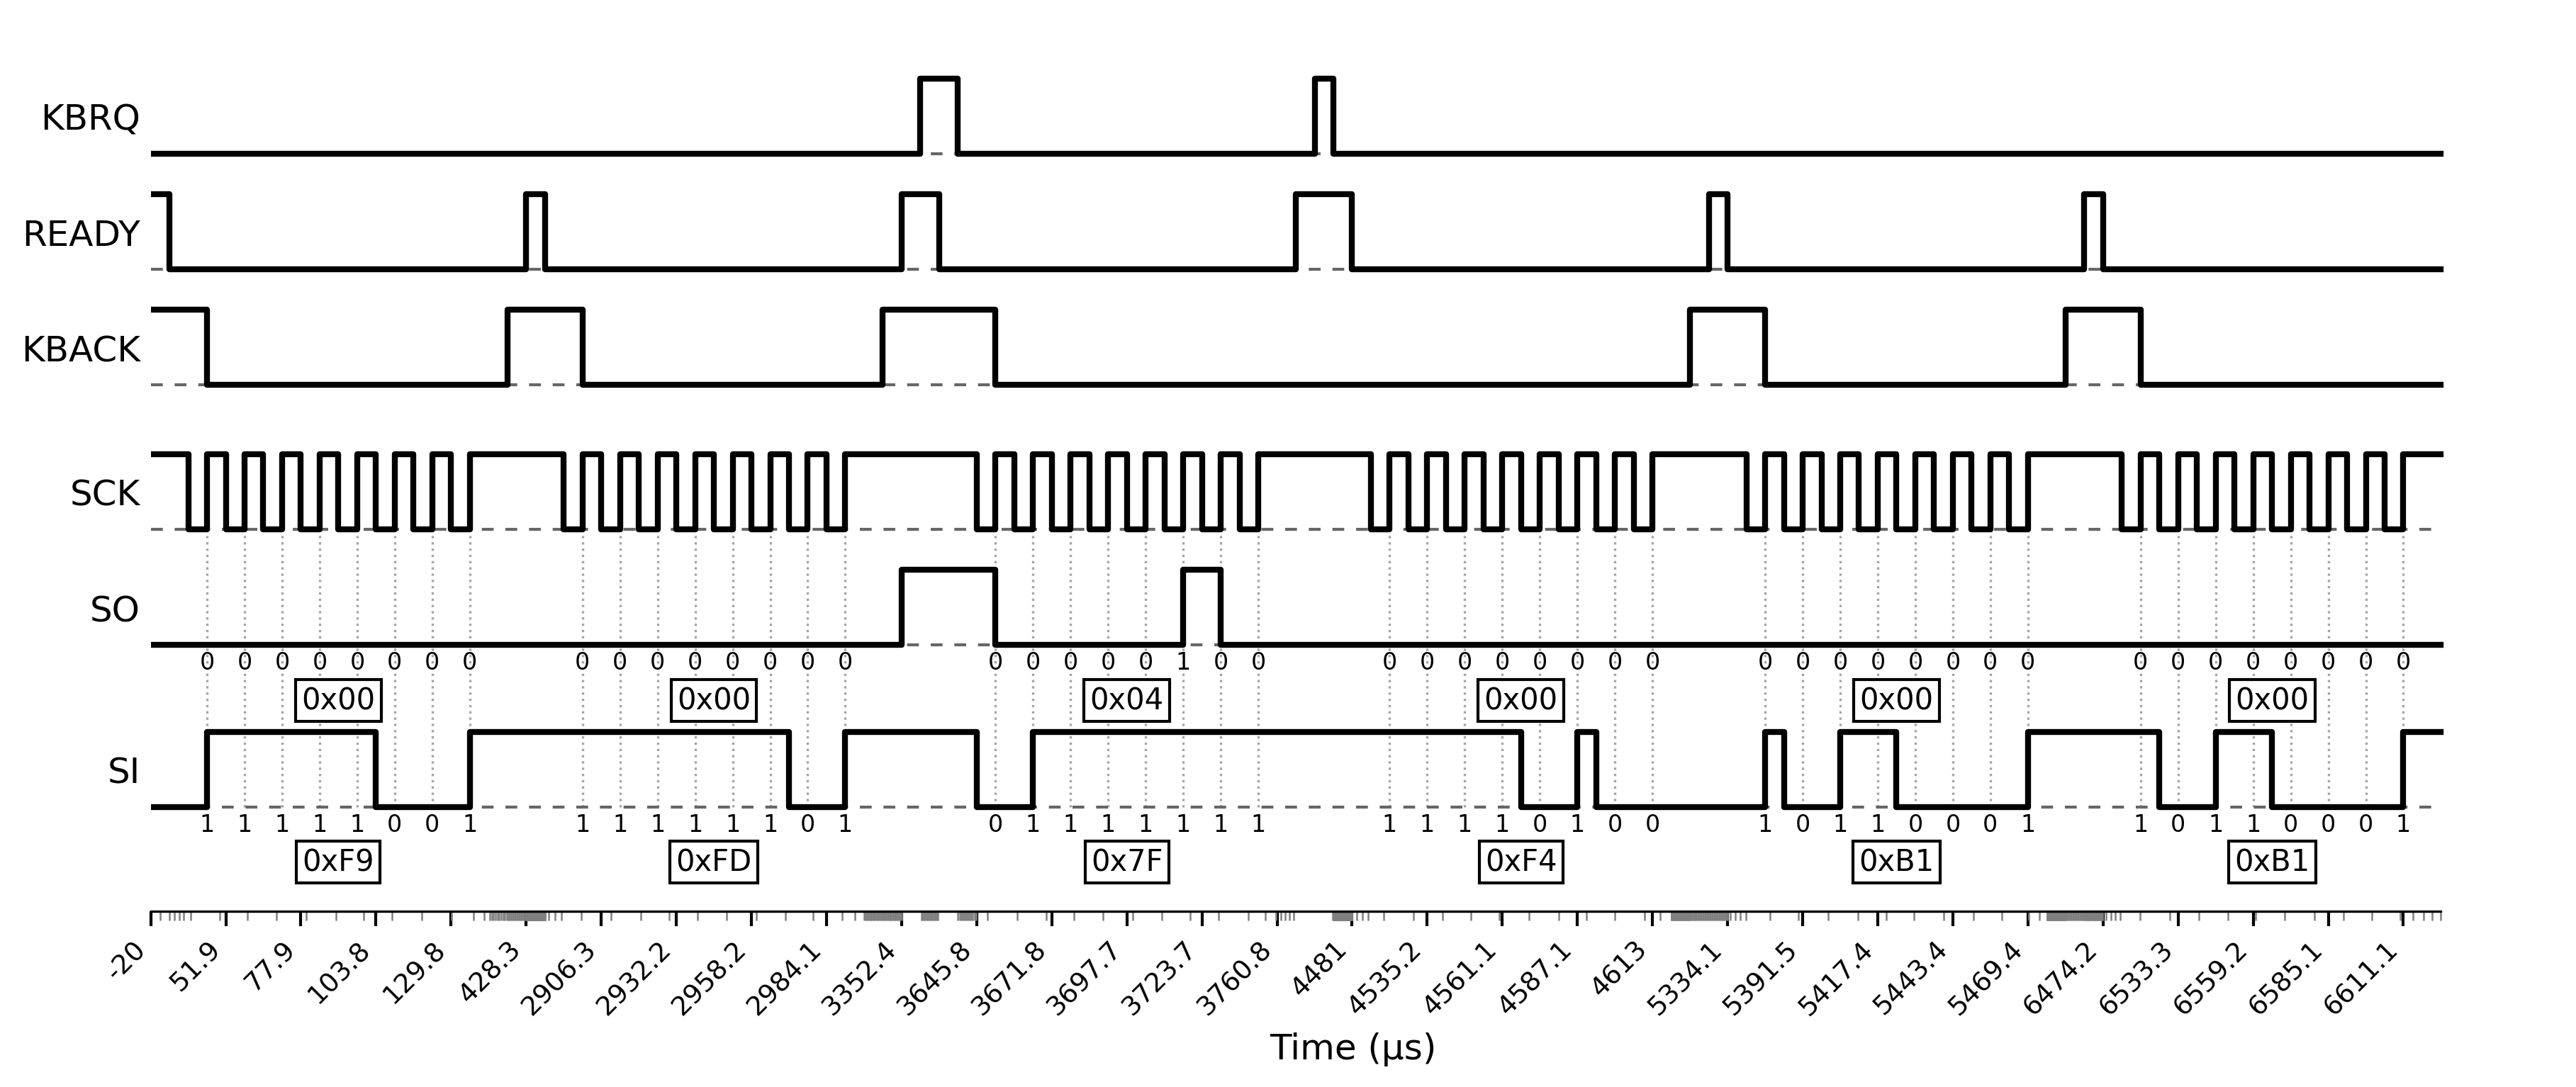

--- capture_AX20_IF60_SELECT ---


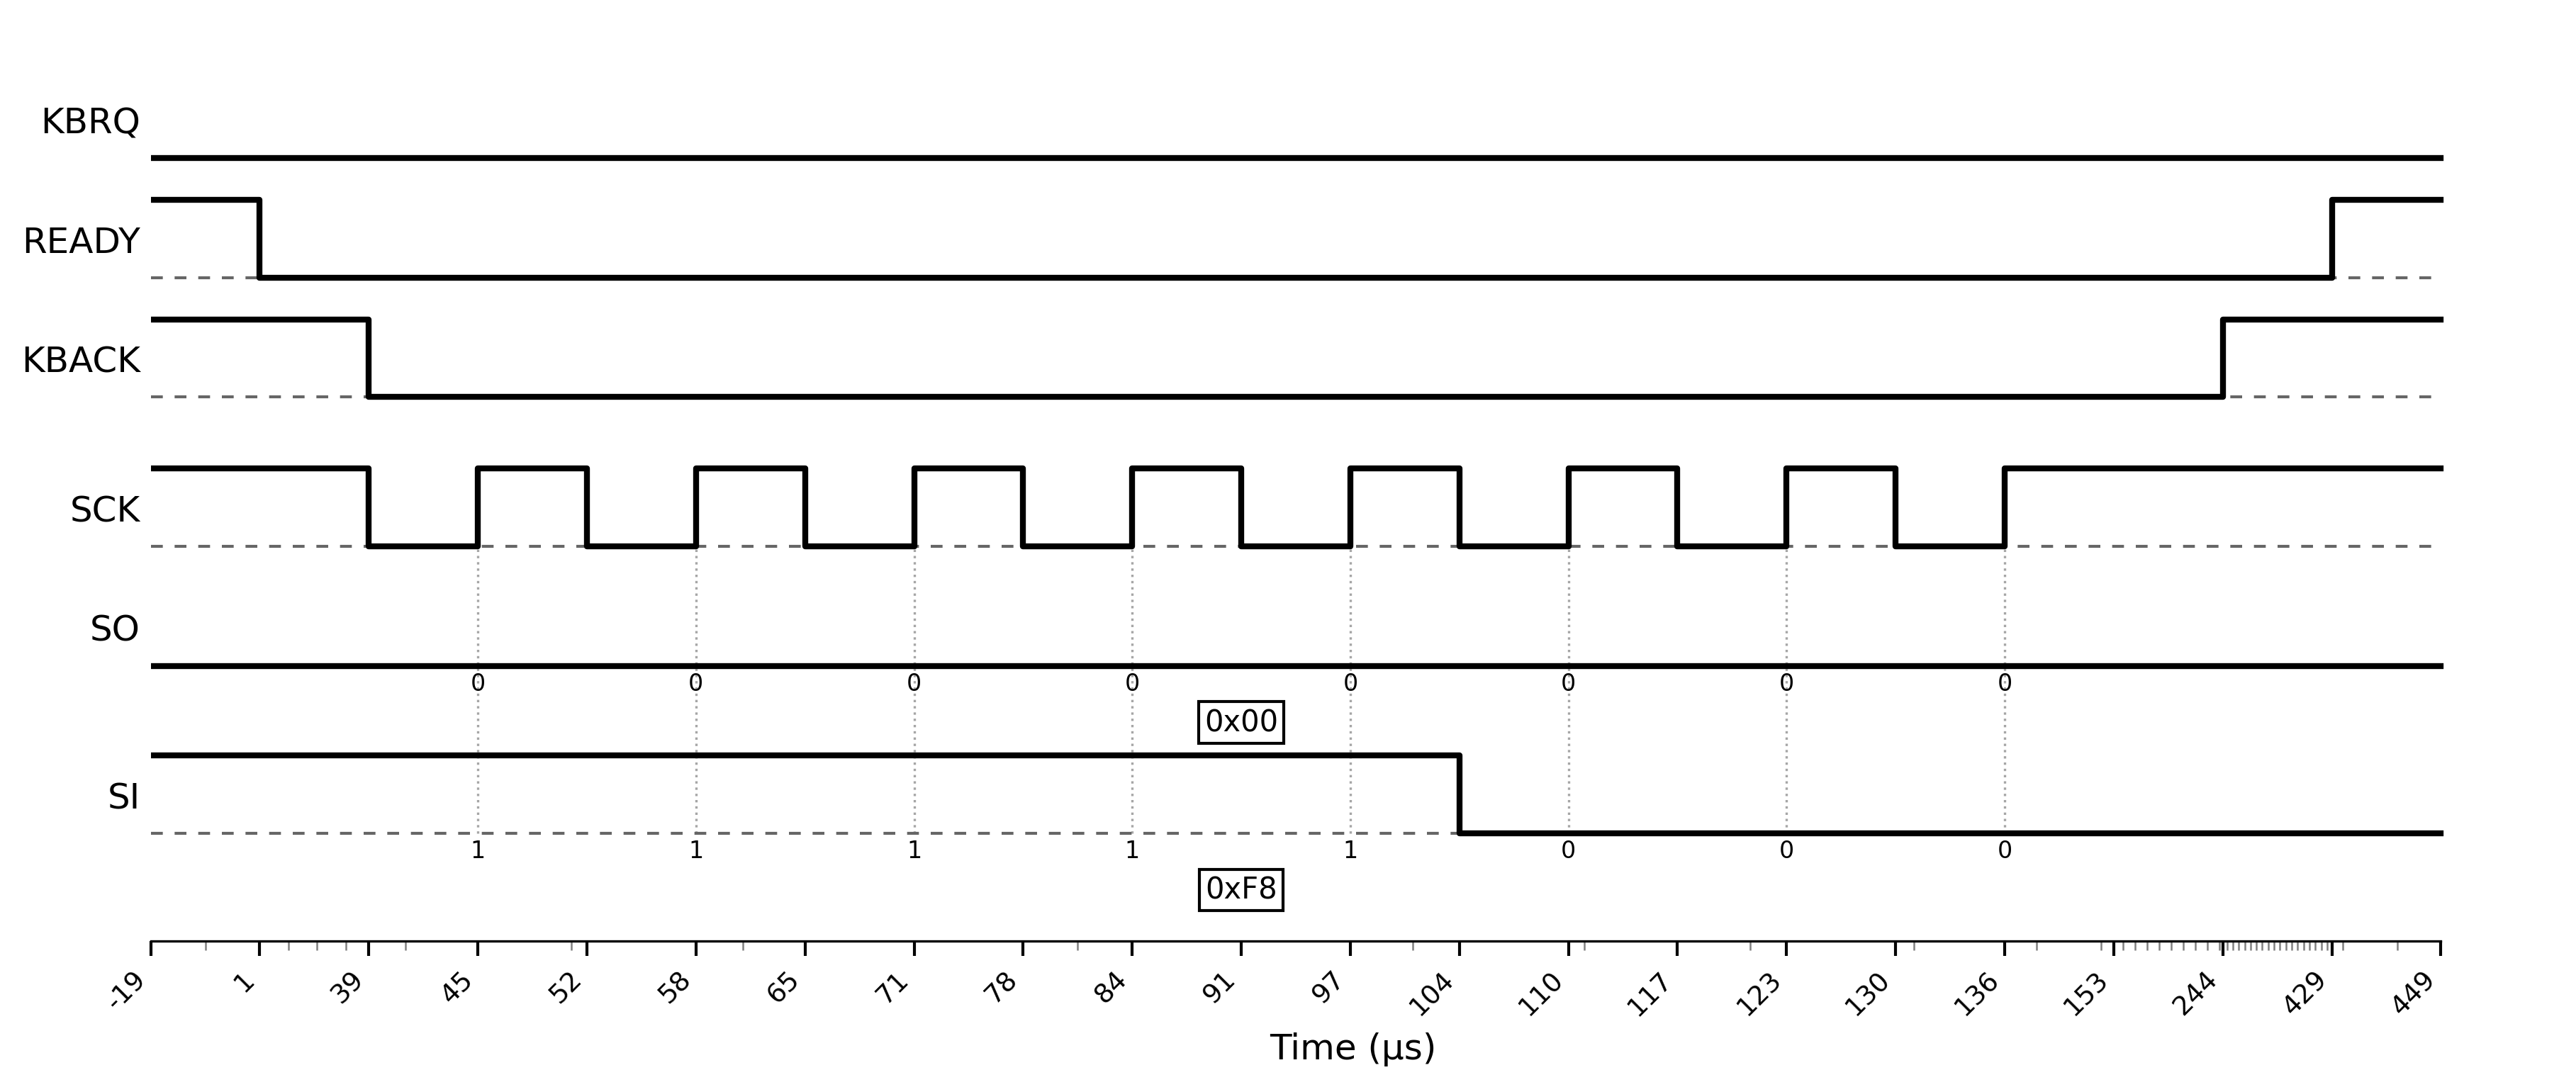

--- capture_AX20_IF60_DESELECT ---


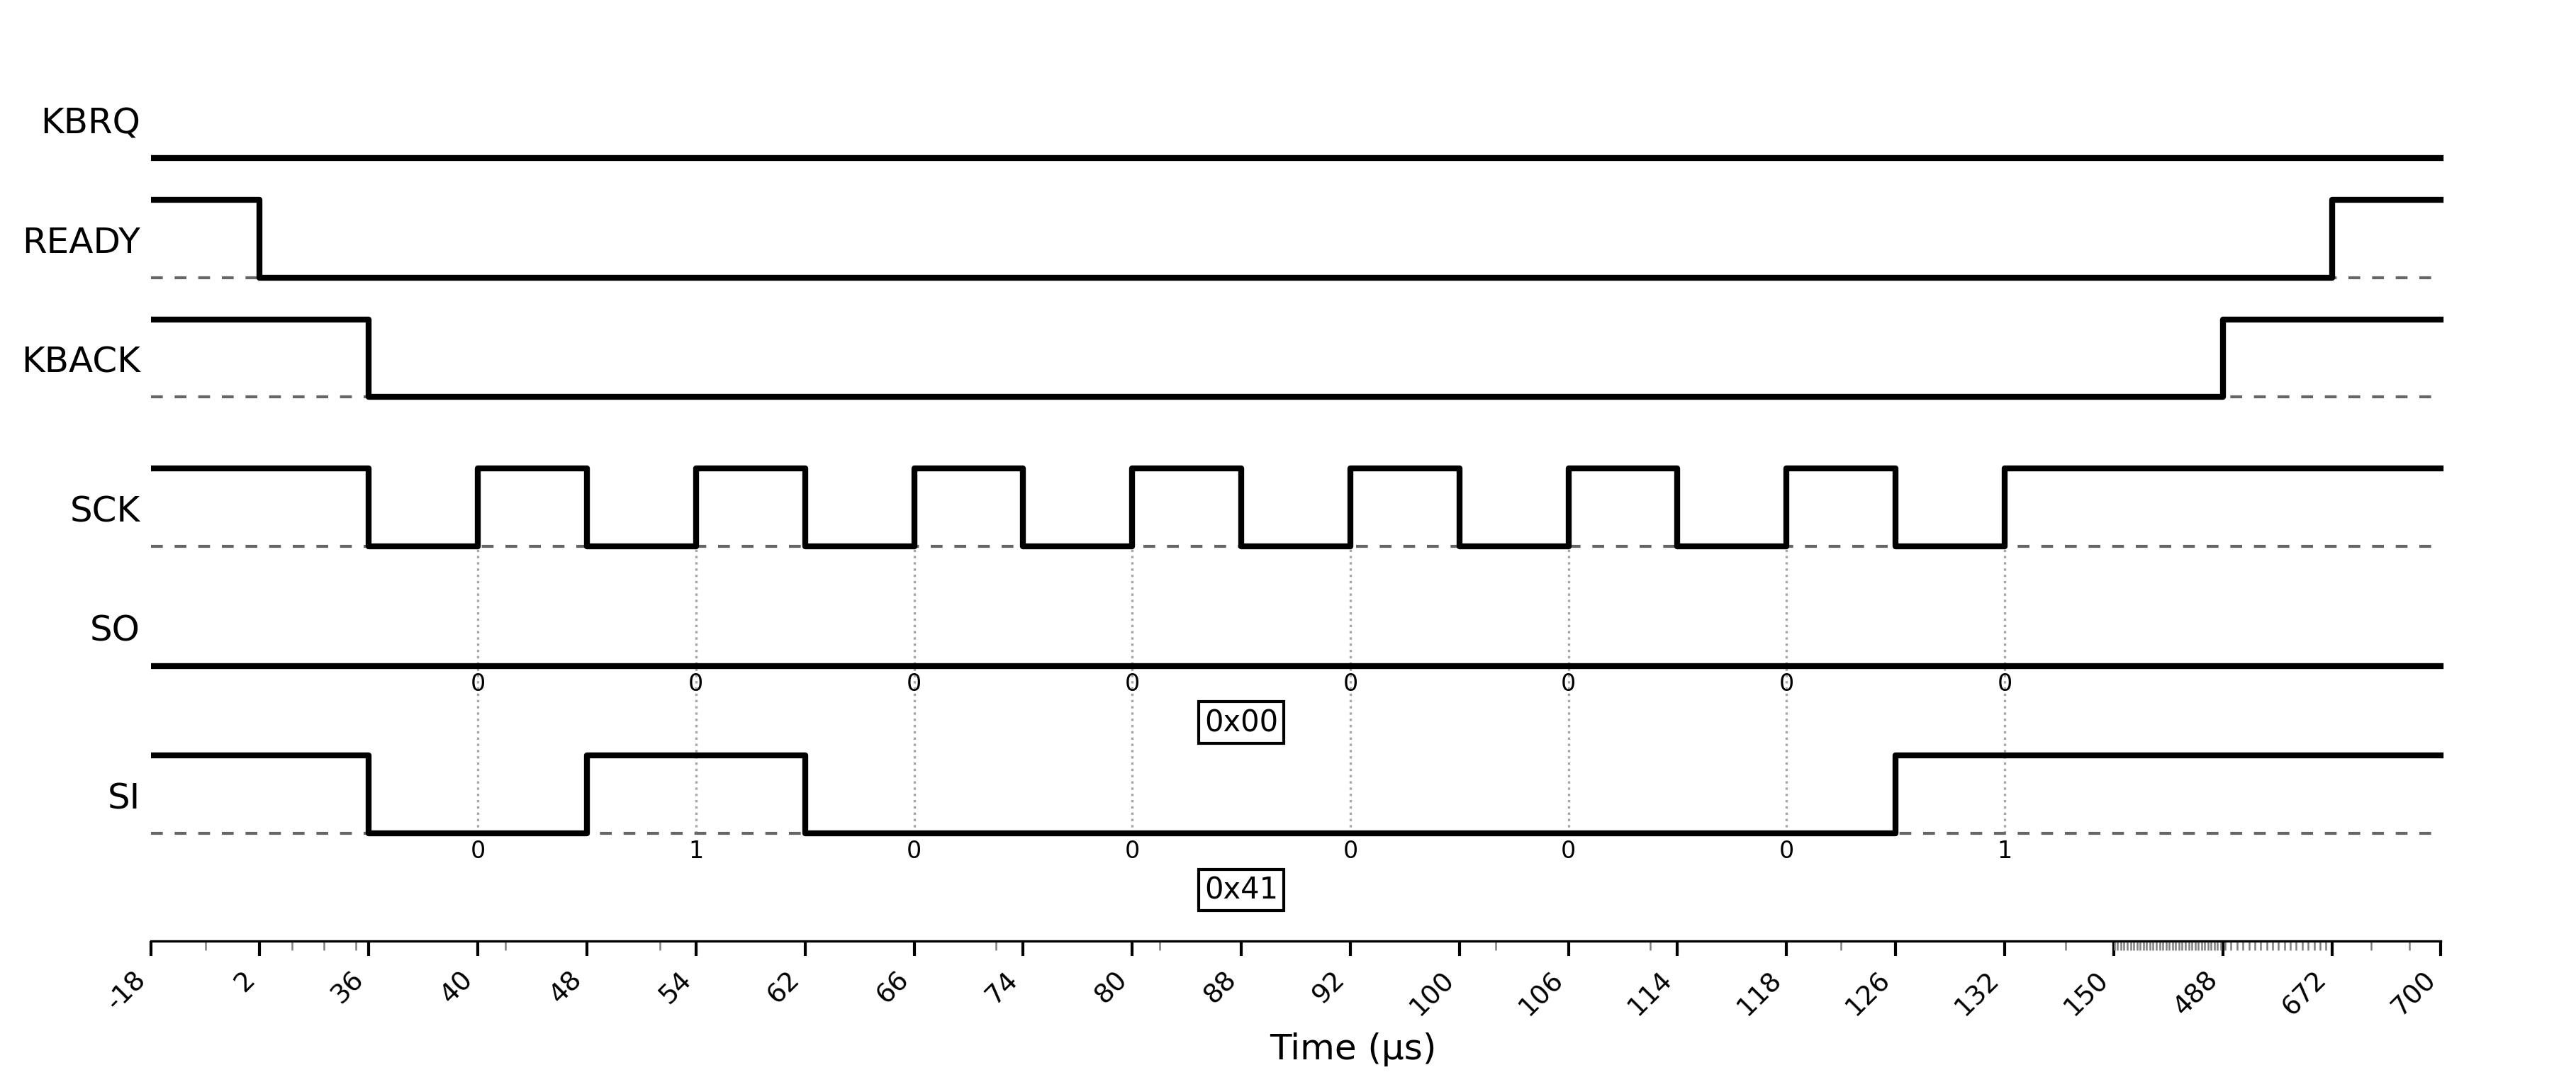

--- capture_AX20_IF60_ASCII_65 ---


In [4]:
figures = {}

# IF-60 captures (indices 0–3)
for config in CAPTURES[:4]:
    name, fig = process_capture(config)
    figures[name] = fig
    plt.show()
    print(f"--- {name} ---")

## Adapter Captures with Debug Pins (Anhang J + Kap. 5)
POWERON and ASCII A — 10 channels (6 standard + 4 debug).

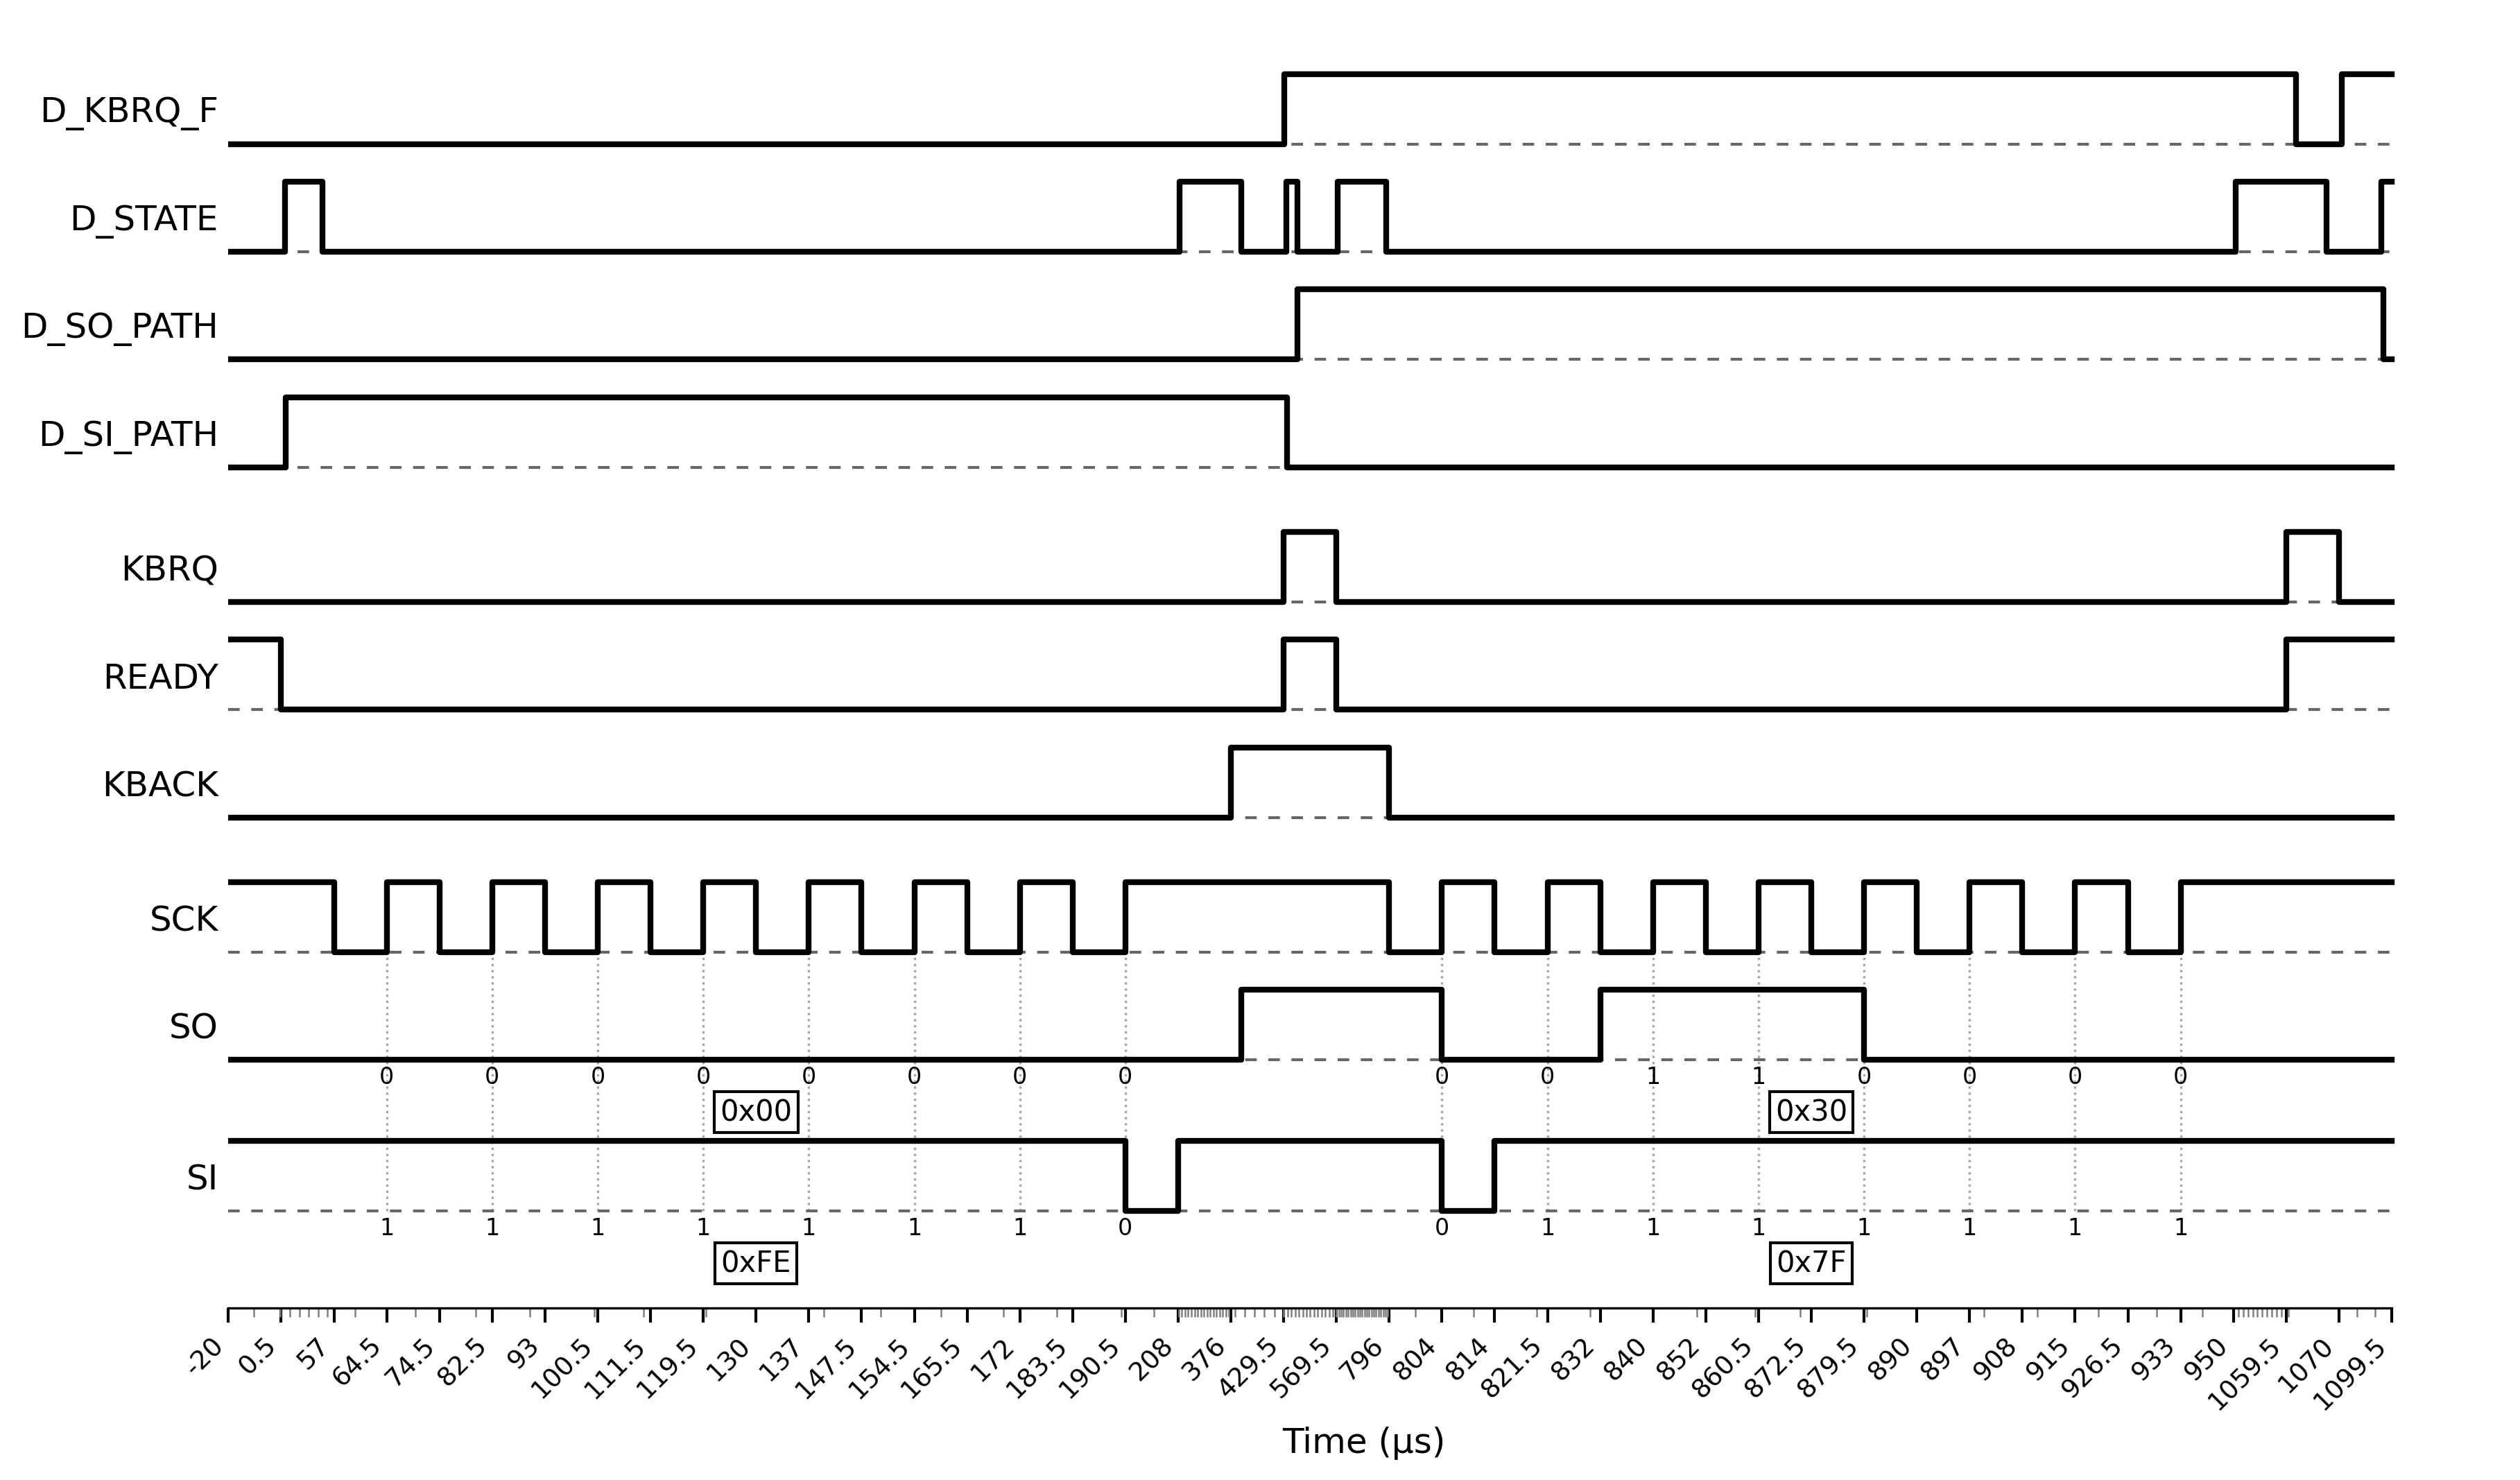

--- capture_AX20_ADAPTER_POWERON ---


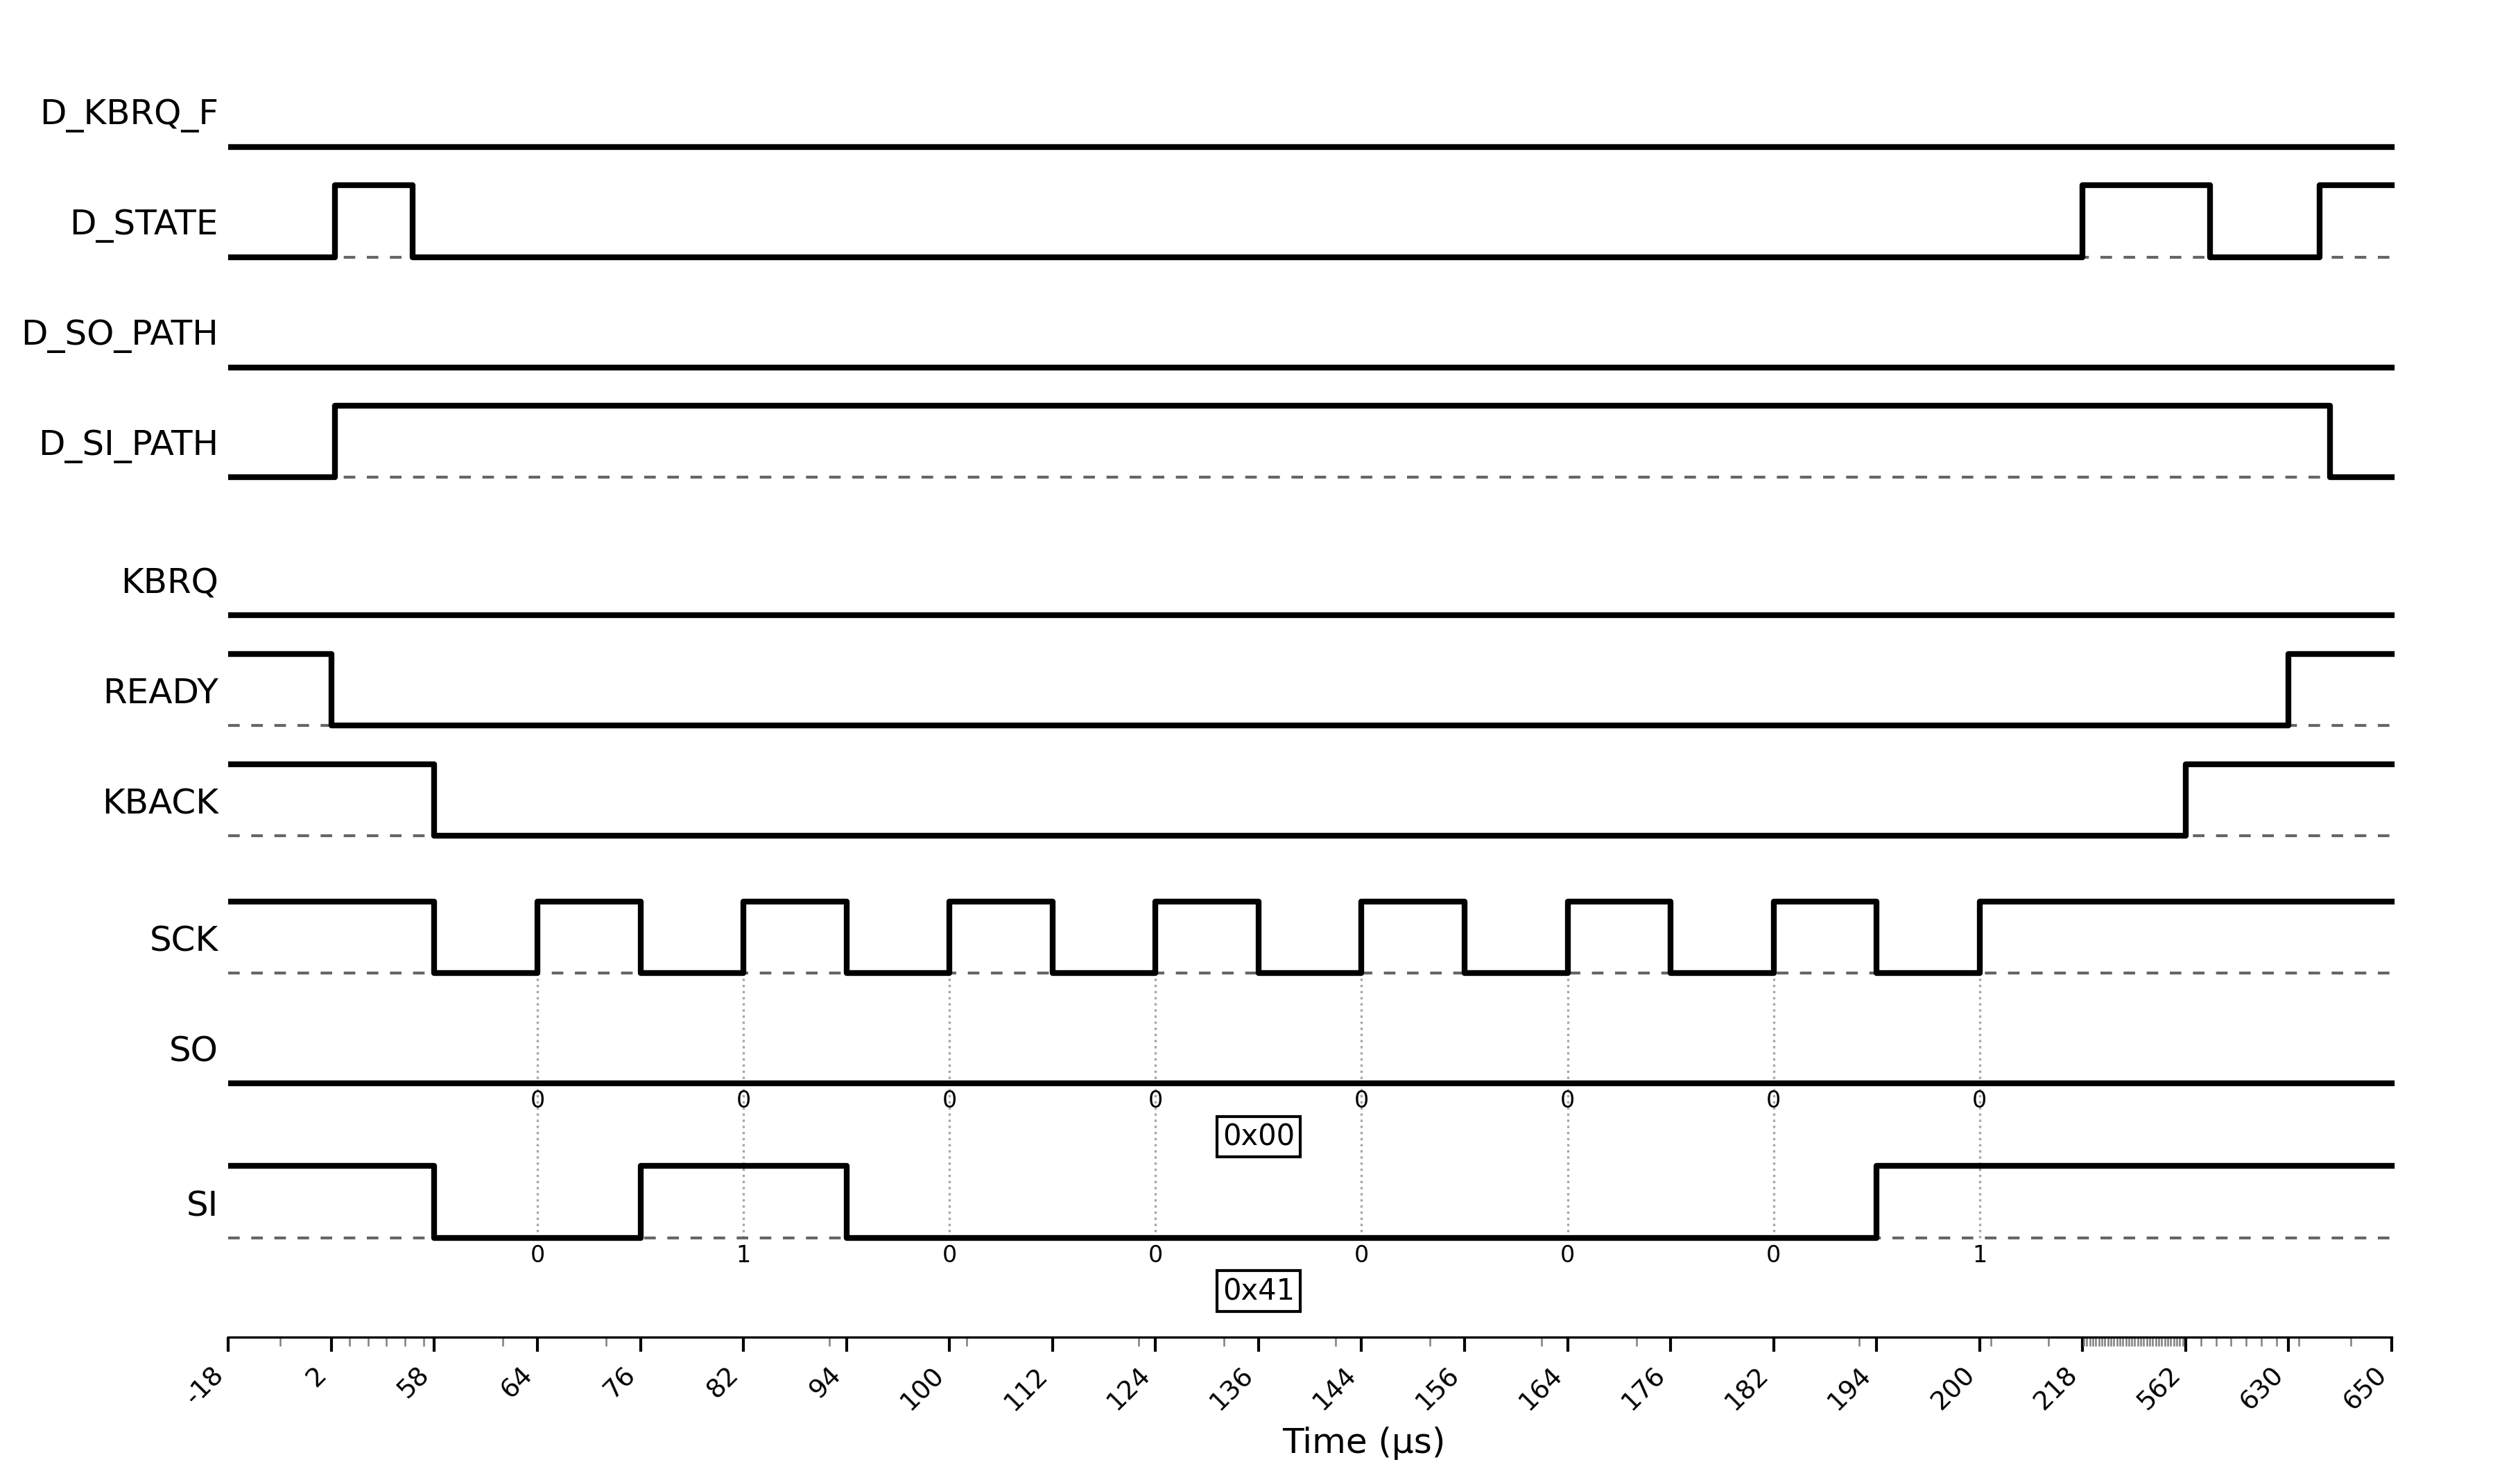

--- capture_AX20_ADAPTER_ASCII_65 ---


In [5]:
# Adapter captures (indices 4–5)
for config in CAPTURES[4:]:
    name, fig = process_capture(config)
    figures[name] = fig
    plt.show()
    print(f"--- {name} ---")

## Raw Captures — Echter Signalverlauf (Kap. 4 Intro)
Kein Zeitwarp, keine Dekodierung. Für `fig:einstieg_capture` in Kap. 4.

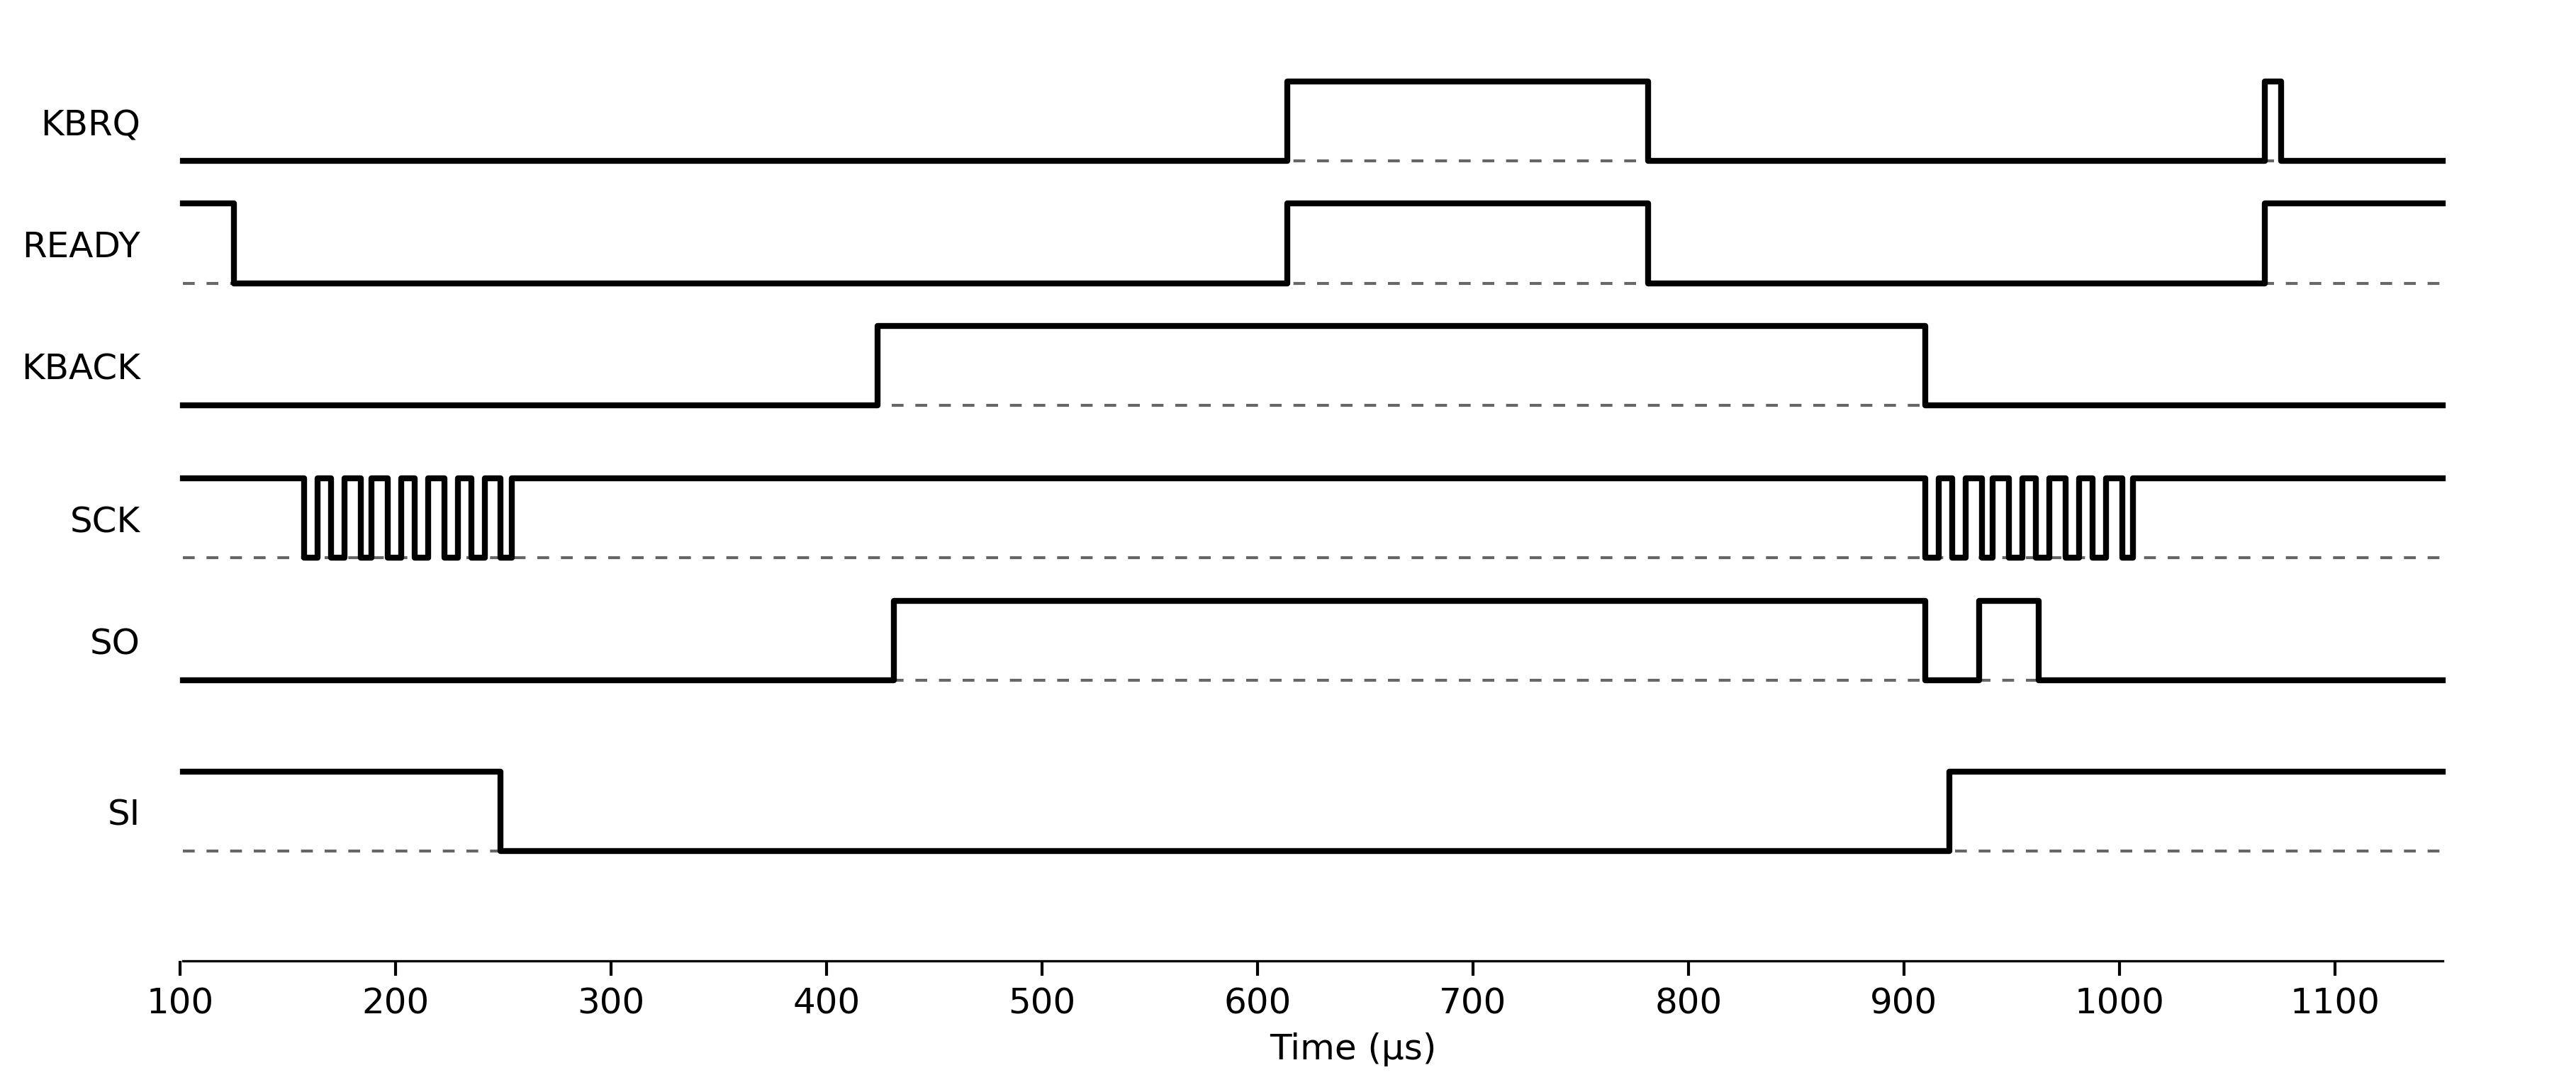

--- capture_AX20_IF60_POWERON_intro ---


In [6]:
# Raw captures: no normalization, no decoding
for config in RAW_CAPTURES:
    name, fig = process_capture_raw(config)
    figures[name] = fig
    plt.show()
    print(f"--- {name} ---")


## SVG Export
Export all figures to `svg_output/`. Run after visual inspection.

In [7]:
Path(OUTPUT_DIR).mkdir(exist_ok=True)
for name, fig in figures.items():
    svg_path = f"{OUTPUT_DIR}/{name}.svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    print(f"Saved: {svg_path}")

Saved: ./svg_output/capture_AX20_IF60_POWERON.svg


Saved: ./svg_output/capture_AX20_IF60_SELECT.svg
Saved: ./svg_output/capture_AX20_IF60_DESELECT.svg


Saved: ./svg_output/capture_AX20_IF60_ASCII_65.svg
Saved: ./svg_output/capture_AX20_ADAPTER_POWERON.svg


Saved: ./svg_output/capture_AX20_ADAPTER_ASCII_65.svg
Saved: ./svg_output/capture_AX20_IF60_POWERON_intro.svg
